# Order-Backlog Drift — a quantitative teardown 🔬
### The RPO-growth calendar long-short + Newey-West *t* · the era split that kills it · a 534-style pooled event-drift placebo · the RPO→sales mechanism regression · a cost/borrow sweep · a 20-seed synthetic positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Backlog-leads-sales%3F: Confirmed](https://img.shields.io/badge/Backlog--leads--sales%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **YoY growth in Remaining Performance Obligations (RPO / signed backlog) is a leading fundamental the market underreacts to** — is a cross-sectional return-predictability claim, distinct from the *deferred-revenue* balance (sibling 798), from *realised* sales growth (199), and from a revenue-*surprise* PEAD (534). The job: measure it honestly on the only sample that exists (post-ASC-606, one regime), and be clear about what that sample can and cannot certify.

> ⚠️ **Data note.** 38 enterprise-software names; RPO from EDGAR `companyconcept` (`RevenueRemainingPerformanceObligation`), point-in-time at the filing date; prices yfinance total-return. **RPO didn't exist before 2018** — the long-short runs 2019-06 → 2026-06 (85 months). Survivorship named on the Signal axis (current-survivors basket). Numbers in [`docs/results.md`](../docs/results.md) (fingerprint `243982cf416a`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from order_backlog import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    LS = st.calendar_ls(PRICES, EVENTS, signal_col="rpo_yoy", n_buckets=3,
                        min_names=6, staleness_days=200)
else:
    PRICES = EVENTS = LS = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if EVENTS is None else EVENTS['ticker'].nunique()),
      "| RPO events:", (0 if EVENTS is None else len(EVENTS)),
      "| LS months:", (0 if LS is None else len(LS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fp': '243982cf416a', 'n_names': 38, 'n_events': 842, 'filed_start': '2018-10-24', 'filed_end': '2026-06-24', 'price_start': '2017-01-03', 'n_months': 85, 'ls_start': '2019-06', 'ls_end': '2026-06', 'avg_n': 29.3, 'avg_turnover': 0.11, 'gross_bps': 100.0, 'gross_ann': 12.0, 'sharpe': 0.57, 'hit': 57.6, 'hit_k': 49, 'hit_n': 85, 'wilson': (47.0, 67.6), 'long_bps': 220.6, 'short_bps': 120.6, 'long_ann': 26.5, 'short_ann': 14.5, 't_iid': 1.51, 't_nw': 1.1, 'net10_bps': 89.4, 'net10_ann': 10.7, 'net10_tnw': 0.99, 'net10_sharpe': 0.51, 'net20_bps': 87.2, 'net20_ann': 10.5, 'net20_tnw': 0.96, 'net20_sharpe': 0.49, 'era_split': '2022-01-01', 'era_early_n': 31, 'era_early_bps': 244.7, 'era_early_tnw': 1.78, 'era_late_n': 54, 'era_late_bps': 16.9, 'era_late_tnw': 0.17, 'drift': {21: (830, 1.25, 0.99, 0.26, 53, 0.24, 0.4), 63: (805, 5.28, 3.86, 1.41, 51, 0.6, 0.26), 126: (769, 8.88, 5.45, 3.43, 50, 0.98, 0.144)}, 'bucket126': (5.45, 8.48, 8.88), 'placebo126_obs': 3.43, 'placebo126_mean': 0.0, 'placebo126_p': 0.144, 'lead_n': 465, 'lead_slope': 0.313, 'lead_t': 9.92, 'lead_r2': 0.175, 'lead_corr': 0.42, 'lead_top_sales': 39.4, 'lead_bot_sales': 18.6, 'lead_spread': 20.8, 'rpo_median': 25.5, 'rpo_p10': 3.5, 'rpo_p90': 60.0, 'syn_null_mean': -0.37, 'syn_null_sd': 0.85, 'syn_null_fire': 1, 'syn_planted_bps': 198.7, 'syn_planted_t': 3.79}


real cache present: True | names: 38 | RPO events: 842 | LS months: 85


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | calendar LS **+100 bps/mo** (~+12%/yr, Sharpe 0.57) but **NW *t* = 1.10** (< 2); pooled drift monotone, max *t* = 0.98 (126d); edge concentrated 2019-21 (245 bps/mo) vs 2022+ (17, *t* = 0.17) |
| **Tradability** | `MIRAGE` | net @20bps+borrow **87 bps/mo**, NW *t* = 0.96, Sharpe 0.49 |
| **Backlog leads sales?** | `CONFIRMED` | next_rev_yoy ~ rpo_yoy slope **+0.31** (*t* = +9.9), tercile spread **+21 pp** |

> 💡 In plain words: the fundamental lead is unambiguous (backlog → sales), the return long-short is the right sign everywhere and even looks tradable on paper — but the autocorrelation-robust statistic never clears 2, and the whole thing is a 2019-21 bull-market ghost. Real fundamental, uncertified mispricing.

## 1 · The claim, steelmanned

Let $B_{i,q}$ be name $i$'s total RPO at fiscal quarter-end $q$, disclosed on filing date $f_{i,q}$. Signal: YoY growth $g_{i,q} = B_{i,q}/B_{i,q-4} - 1$, known at $f_{i,q}$. The claims:

- **H₁ (lead).** $g$ predicts next-quarter revenue growth — the accounting lead.
- **H₂ (drift).** High-$g$ names out-return low-$g$ names *after* $f$, because the market underreacts to the disclosed backlog.
- **H₃ (capture).** A monthly-rebalanced tercile long-short banks that drift net of costs and borrow.

We find **H₁ strongly supported** (slope +0.31, *t* = +9.9, +21 pp tercile spread), **H₂ only weakly and unstably supported** (right sign at every horizon, but NW *t* = 1.10 and concentrated in 2019-21), **H₃ not supported** (net NW *t* = 0.96). The decisive statistic is the monthly long-short's Newey-West *t*; the honest finding is that the *fundamental* lead is real but the *return* underreaction is uncertifiable on this tape.

## 2 · So what? — inference design

Monthly long-short returns are **persistent and overlapping** (a quarterly signal held across months, in a tightly-correlated sector), so i.i.d. *t* overstates significance — the planned primary is the **Newey-West (6-lag) HAC *t*** of the monthly series. The pooled event-drift cross-check carries a **10,000-draw label-shuffle placebo** (permute the signal, re-form random terciles). The era split (2022-01-01, the early-ASC-606 / mature boundary named ex ante) is reported as **within-era HAC *t*'s**, not eyeballed. The monthly hit rate carries a **Wilson interval**. One documented execution lag throughout (signal at month *t*, return of *t+1*); costs one-way × NAV × turnover on both legs; short pays borrow.

## 3 · How we'd know — the protocol

- **Panel.** 38 names, 842 RPO-YoY events, filings 2018-10-24 → 2026-06-24. Median RPO growth ≈ 26% (p10 4%, p90 60%) — a wide, real cross-section.
- **Primary.** Monthly tercile long-short, NW(6) *t* + one-sample *t* + Wilson hit rate; gross and net (10/20 bps + 100 bps borrow).
- **Cross-check.** Pooled event drift at 21/63/126d, top-minus-bottom, one-sample *t* + placebo.
- **Mechanism.** Pooled OLS next_rev_yoy ~ rpo_yoy (slope, *t*, R², tercile spread).
- **Era.** 2019-21 vs 2022+, within-era HAC *t*.
- **Control.** Synthetic panel, planted forward-return knob; the null must not fire across 20 seeds, a planted edge must light up.

## 4 · The teardown

### 4a · The primary calendar long-short and its Newey-West *t*

Monthly tercile long-short, one execution lag. The decisive number is the HAC *t*.

months=85  avg X-section=29.3  avg one-way turnover=0.11
gross LS +100.0 bps/mo (~+12.0%/yr)  Sharpe 0.57  hit 58%
long +220.6  short +120.6 bps/mo
one-sample t = +1.51   Newey-West(6) t = +1.10


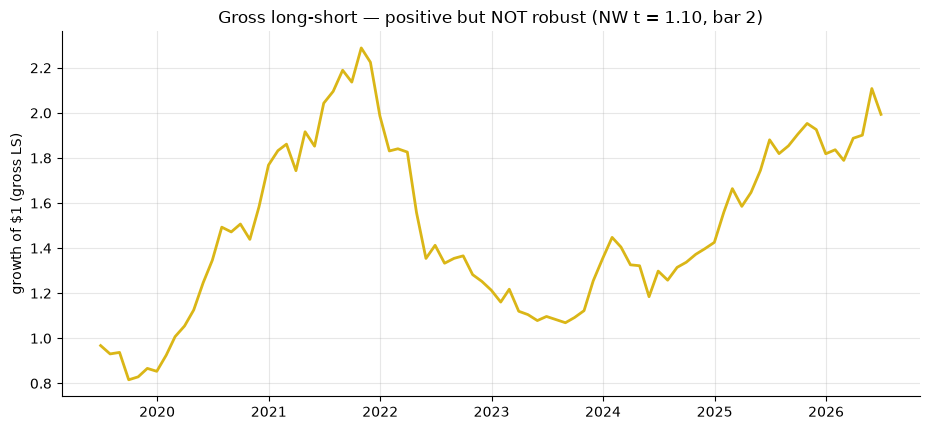

In [2]:
if HAVE_REAL:
    s = st.calendar_ls_stats(LS)
    print(f"months={s['n_months']}  avg X-section={s['avg_n']:.1f}  "
          f"avg one-way turnover={s['avg_turnover']:.2f}")
    print(f"gross LS {s['mean_bps']:+.1f} bps/mo (~{s['ann_pct']:+.1f}%/yr)  "
          f"Sharpe {s['sharpe']:.2f}  hit {s['hit']*100:.0f}%")
    print(f"long {s['long_bps']:+.1f}  short {s['short_bps']:+.1f} bps/mo")
    print(f"one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}")
    cum = (1 + LS['ls']).cumprod(); x, y = cum.index, cum.values
    tnw = s['t_nw']
else:
    tnw = R['t_nw']
    rng = np.random.default_rng(799)
    y = np.cumprod(1 + rng.normal(R['gross_bps']/1e4, 0.05, R['n_months']))
    x = pd.date_range('2019-06-30', periods=R['n_months'], freq='ME')
    print(f"(offline) gross {R['gross_bps']:+.0f} bps/mo, NW t = {tnw:+.2f}")
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(x, y, color=(GREEN if tnw>=2 else AMBER), lw=2)
ax.set_ylabel('growth of $1 (gross LS)')
ax.set_title(f'Gross long-short — positive but NOT robust (NW t = {tnw:.2f}, bar 2)')
plt.tight_layout(); plt.show()

> 💡 In plain words: **+100 bps/mo** and Sharpe 0.57 look like a real trade, and one-sample *t* = 1.51 would almost tempt you — but once you correct for the serial correlation in these overlapping monthly returns, **NW *t* = 1.10**. The hit rate is 58% (Wilson 95% [47%, 68%]) — the lower bound is below 50%. Not certified.

### 4b · The era split — where the "edge" actually lives

Within-era HAC *t*, boundary 2022-01-01 (early-ASC-606 boom vs mature panel).

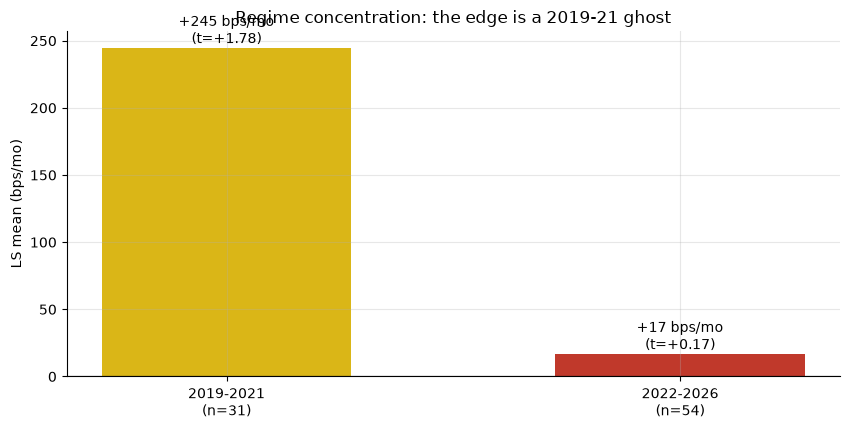

2019-21 +245 bps/mo (t=+1.78)  |  2022+ +17 bps/mo (t=+0.17)


In [3]:
if HAVE_REAL:
    e = LS[LS.index < data.ERA_SPLIT]['ls'].to_numpy()
    l = LS[LS.index >= data.ERA_SPLIT]['ls'].to_numpy()
    eb, lb, et, lt = e.mean()*1e4, l.mean()*1e4, st.newey_west_t(e), st.newey_west_t(l)
    ne, nl = len(e), len(l)
else:
    eb, lb, et, lt = R['era_early_bps'], R['era_late_bps'], R['era_early_tnw'], R['era_late_tnw']
    ne, nl = R['era_early_n'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar([f'2019-2021\n(n={ne})', f'2022-2026\n(n={nl})'], [eb, lb],
       color=[AMBER, RED], width=.55)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]):
    ax.annotate(f'{v:+.0f} bps/mo\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('LS mean (bps/mo)')
ax.set_title('Regime concentration: the edge is a 2019-21 ghost')
plt.tight_layout(); plt.show()
print(f'2019-21 {eb:+.0f} bps/mo (t={et:+.2f})  |  2022+ {lb:+.0f} bps/mo (t={lt:+.2f})')

> 💡 In plain words: **+245 bps/mo** in 2019-21 vs **+17 bps/mo** since 2022 (*t* = +0.17). The signal didn't decay gently — it switched off. Anything that only pays in the 2020-21 growth-stock mania is indistinguishable from a long-duration-growth beta that happened to correlate with backlog momentum in that window.

### 4c · The pooled event drift and its placebo

534-style: bucket every filing event by RPO growth, top-minus-bottom forward drift, entered one session after the filing; 10,000-draw label-shuffle placebo. In the notebook we run a lighter placebo and quote the canonical p from `results.md`.

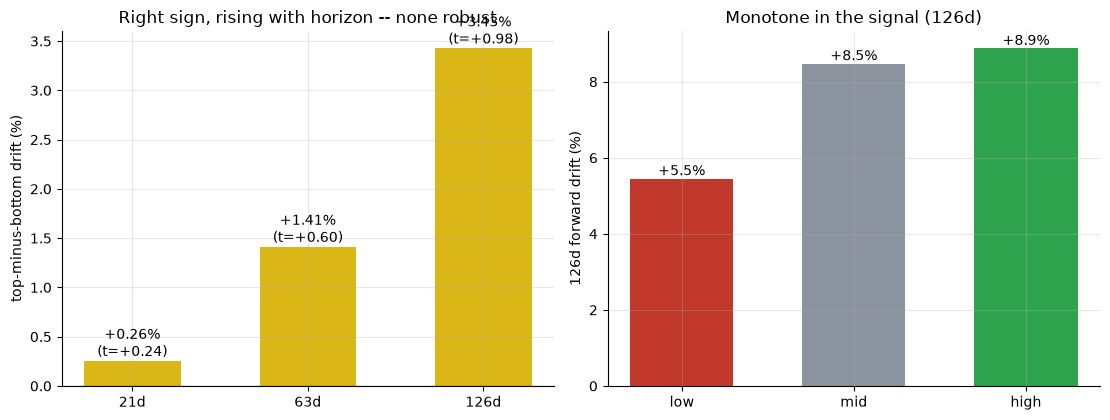

LS by horizon %: [0.26, 1.41, 3.43]  t: [0.24, 0.6, 0.98]
canonical 126d: LS +3.43% vs placebo mean +0.00%, p = 0.144


In [4]:
hs = list(R['drift'].keys())
if HAVE_REAL:
    ls_by_h, t_by_h = [], []
    for h in hs:
        e = st.event_summary(PRICES, EVENTS, horizon=h, n_buckets=3, lag=1,
                             placebo=True, n_draws=2000)
        ls_by_h.append(e['ls_mean']*100); t_by_h.append(e['t'])
    bm = st.bucket_means(st.event_drift_frame(PRICES, EVENTS, 126, lag=1), 3)*100
else:
    ls_by_h = [R['drift'][h][3] for h in hs]; t_by_h = [R['drift'][h][5] for h in hs]
    bm = np.array(R['bucket126'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar([f'{h}d' for h in hs], ls_by_h, color=[AMBER]*len(hs), width=.55)
for i,(v,t_) in enumerate(zip(ls_by_h, t_by_h)):
    a1.annotate(f'{v:+.2f}%\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('top-minus-bottom drift (%)')
a1.set_title('Right sign, rising with horizon -- none robust')
a2.bar(['low','mid','high'], bm, color=[RED, GREY, GREEN], width=.6)
for i,v in enumerate(bm): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('126d forward drift (%)'); a2.set_title('Monotone in the signal (126d)')
plt.tight_layout(); plt.show()
print('LS by horizon %:', [round(v,2) for v in ls_by_h], ' t:', [round(t,2) for t in t_by_h])
print(f"canonical 126d: LS +{R['placebo126_obs']:.2f}% vs placebo mean "
      f"{R['placebo126_mean']:+.2f}%, p = {R['placebo126_p']:.3f}")

> 💡 In plain words: the drift is the **right sign at every horizon** and rises monotonically with the signal (5.5% / 8.5% / 8.9% low→high at 126d), and it *grows* with horizon (+0.26% → +3.43%) exactly as a slow underreaction would — but the best horizon is *t* = 0.98, placebo **p = 0.144**. Suggestive, never significant.

### 4d · The mechanism — backlog really does lead sales

Pooled OLS: next-quarter revenue YoY growth on this-quarter RPO YoY growth.

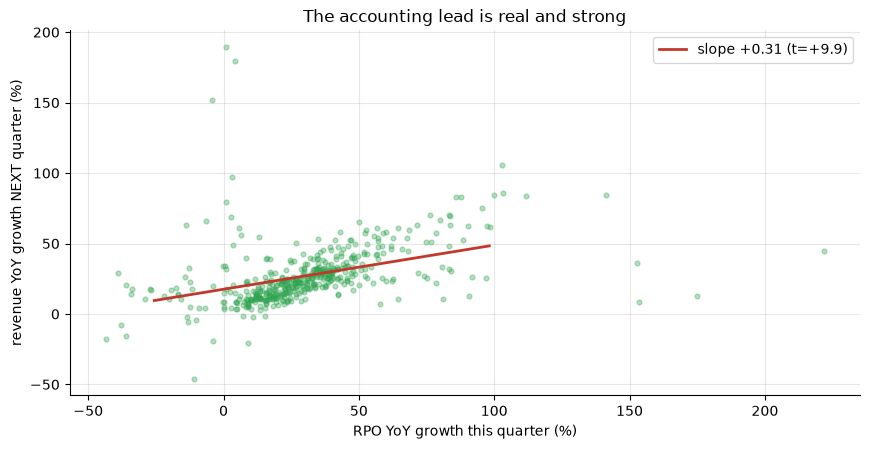

slope +0.313 (t=+9.92, R2=0.175); next-q sales top +39.4% vs bot +18.6%


In [5]:
if HAVE_REAL:
    ld = st.leads_sales(EVENTS)
    slope, tt, r2 = ld['slope'], ld['t'], ld['r2']
    top_s, bot_s = ld['top_sales']*100, ld['bot_sales']*100
    fr = EVENTS.dropna(subset=['rpo_yoy','next_rev_yoy'])
    xx = fr['rpo_yoy'].to_numpy()*100; yy = fr['next_rev_yoy'].to_numpy()*100
else:
    slope, tt, r2 = R['lead_slope'], R['lead_t'], R['lead_r2']
    top_s, bot_s = R['lead_top_sales'], R['lead_bot_sales']
    rng = np.random.default_rng(1); xx = rng.normal(30,25,R['lead_n'])
    yy = 0.313*xx + rng.normal(15,20,R['lead_n'])
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(xx, yy, s=12, alpha=.35, color=GREEN)
xs = np.linspace(np.nanpercentile(xx,2), np.nanpercentile(xx,98), 50)
b0 = (np.nanmean(yy) - slope*np.nanmean(xx))
ax.plot(xs, b0 + slope*xs, color=RED, lw=2, label=f'slope {slope:+.2f} (t={tt:+.1f})')
ax.set_xlabel('RPO YoY growth this quarter (%)')
ax.set_ylabel('revenue YoY growth NEXT quarter (%)')
ax.set_title('The accounting lead is real and strong')
ax.legend(); plt.tight_layout(); plt.show()
print(f'slope {slope:+.3f} (t={tt:+.2f}, R2={r2:.3f}); next-q sales top {top_s:+.1f}% vs bot {bot_s:+.1f}%')

> 💡 In plain words: this is the part of the thesis that **survives**. Backlog growth predicts next-quarter revenue growth with slope +0.31, *t* = +9.9, and the top-tercile names grow sales **+21 pp** faster. The fundamental lead is genuine — the market just doesn't obviously *misprice* it. (This *t* is iid-pooled across quarter-clustered events, so read it as a large, real effect, not a HAC statistic.)

### 4e · Cost/borrow sweep

One-way × NAV × turnover on both legs, short pays 100 bps/yr borrow.

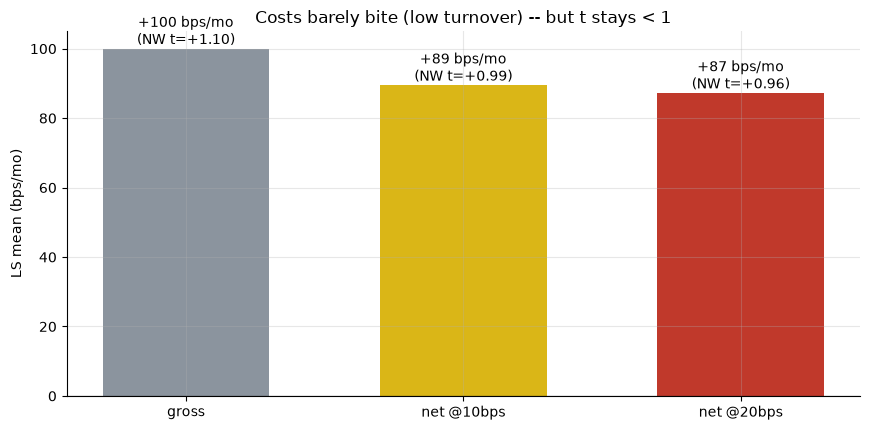

gross +100 (t=+1.10) -> net@20 +87 bps/mo (t=+0.96)


In [6]:
if HAVE_REAL:
    g = st.calendar_ls_stats(LS)['mean_bps']
    n10 = st.calendar_ls_net(LS, 10.0, 100.0); n20 = st.calendar_ls_net(LS, 20.0, 100.0)
    vals = [g, n10['net_mean_bps'], n20['net_mean_bps']]
    ts = [st.calendar_ls_stats(LS)['t_nw'], n10['net_t_nw'], n20['net_t_nw']]
else:
    vals = [R['gross_bps'], R['net10_bps'], R['net20_bps']]
    ts = [R['t_nw'], R['net10_tnw'], R['net20_tnw']]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(['gross','net @10bps','net @20bps'], vals, color=[GREY, AMBER, RED], width=.6)
for i,(v,t_) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.0f} bps/mo\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('LS mean (bps/mo)')
ax.set_title('Costs barely bite (low turnover) -- but t stays < 1')
plt.tight_layout(); plt.show()
print(f'gross {vals[0]:+.0f} (t={ts[0]:+.2f}) -> net@20 {vals[2]:+.0f} bps/mo (t={ts[2]:+.2f})')

> 💡 In plain words: turnover is only ~0.11 (a quarterly signal), so 20 bps + borrow costs the strategy barely anything — net **87 bps/mo**, Sharpe 0.49. But the net **NW *t* = 0.96** is indistinguishable from zero. Costs aren't the killer here; *significance* is. That's a MIRAGE by the desk's definition — a paper Sharpe you can't certify.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic price + RPO-growth panel with a TUNABLE planted forward-return edge (~7-year window matching the real sample). The null (edge = 0) is checked over **20 seeds**.

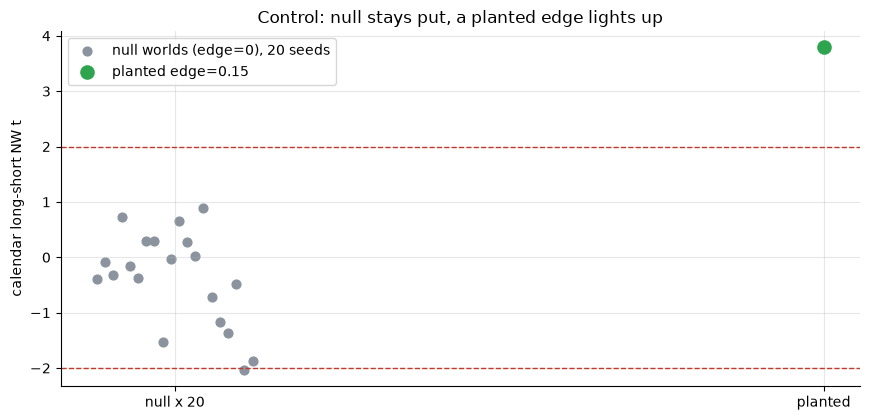

null: mean t = -0.37 (sd 0.85), |t|>=2 in 1/20  |  planted t = +3.79


In [7]:
null_ts = []
for sd in range(20):
    pr, ev = data.synthetic_panel(edge=0.0, seed=799 + sd)
    null_ts.append(st.synthetic_detect(pr, ev)['t_nw'])
null_ts = np.asarray(null_ts)
pr, ev = data.synthetic_panel(edge=0.15, seed=799)
planted_t = st.synthetic_detect(pr, ev)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=90, zorder=5, label='planted edge=0.15')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('calendar long-short NW t')
ax.set_title('Control: null stays put, a planted edge lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = -0.37 (sd 0.85), firing above the bar in only 1/20 (≈ the nominal 5%); a planted edge reads *t* = 3.79. So the machinery is sound and *would* certify a real underreaction — the sub-2 real-tape *t* is an honest reading of a thin, one-regime tape, not a broken pipeline. *(Power check only — never cited for the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — RPO-growth LS **+100 bps/mo** (~+12%/yr, Sharpe 0.57), positively signed on every cut and monotone in the pooled sort — but **NW *t* = 1.10** (< 2), no horizon clears a placebo *p* < 0.05, and the edge is entirely 2019-21 (+245 bps/mo vs +17 since 2022). Literature + mechanism say real; this tape can't certify the mispricing.
- **Tradability `MIRAGE`** — net @20bps+borrow **87 bps/mo**, NW *t* = 0.96, Sharpe 0.49: an uncertified, regime-concentrated paper edge, not a paycheck.
- **Backlog leads sales? `CONFIRMED`** — next_rev_yoy ~ rpo_yoy slope +0.31 (*t* = +9.9), +21 pp tercile spread. The fundamental part of the thesis is genuinely true.

## 6 · Going further

- **The binding constraint is history, not the idea.** RPO is a post-2018 disclosure, so there is one macro regime to test on. The honest statement is *"underpowered,"* not *"debunked"* — a decade more data, or cross-sector RPO beyond software, could move this from WEAK toward REAL.
- **Chase the surviving mechanism.** Backlog → sales is real (*t* ≈ 10). The sharper follow-up is backlog growth → *revenue surprise* (vs consensus), where genuine underreaction would live, and whether the drift concentrates in names where backlog and reported sales *diverge* most.
- **Dedup map:** [798-deferred-revenue-signal](../../798-deferred-revenue-signal/) (billed-but-unrecognised balance; RPO is the larger signed-backlog line), [199-sales-growth](../../199-sales-growth/) (realised sales, which RPO leads), [534-revenue-surprise-drift](../../534-revenue-surprise-drift/) (revenue-surprise PEAD around the print).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*